In [1]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess

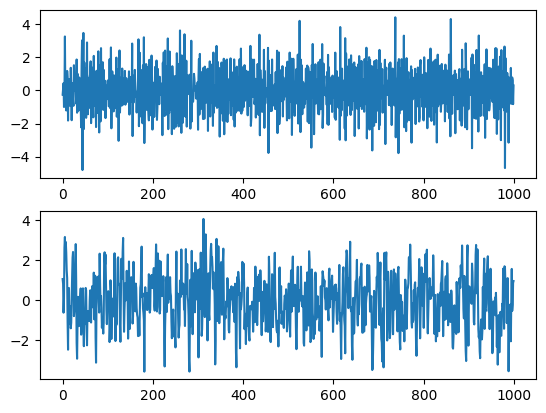

In [2]:
# Plot 1: MA parameter = -0.9
plt.subplot(2, 1, 1)
ar1 = np.array([1])
ma1 = np.array([1, -0.9])

MA_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = MA_object1.generate_sample(nsample = 1000)
plt.plot(simulated_data_1)

# Plot 2: MA parameter = +0.9
plt.subplot(2, 1, 2)
ar2 = np.array([1])
ma2 = np.array([1, 0.9])

MA_object2 = ArmaProcess(ar2, ma2)
simulated_data_2 = MA_object2.generate_sample(nsample = 1000)
plt.plot(simulated_data_2)

plt.show()

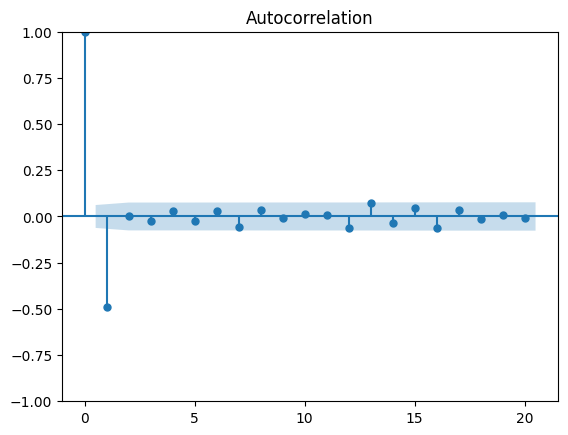

In [3]:
ar1 = np.array([1])
ma1 = np.array([1, -0.9])

MA_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = MA_object1.generate_sample(nsample = 1000)

# Plot 1: MA parameter = -0.9
plot_acf(simulated_data_1, lags = 20)
plt.show()

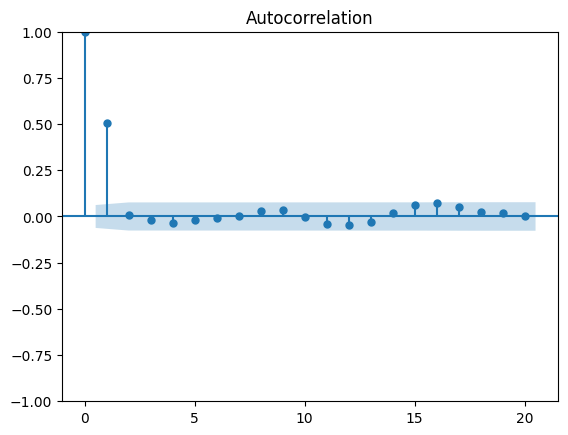

In [4]:
ar2 = np.array([1])
ma2 = np.array([1, 0.9])

MA_object2 = ArmaProcess(ar2, ma2)
simulated_data_2 = MA_object2.generate_sample(nsample = 1000)

# Plot 2: MA parameter = 0.9
plot_acf(simulated_data_2, lags = 20)
plt.show()

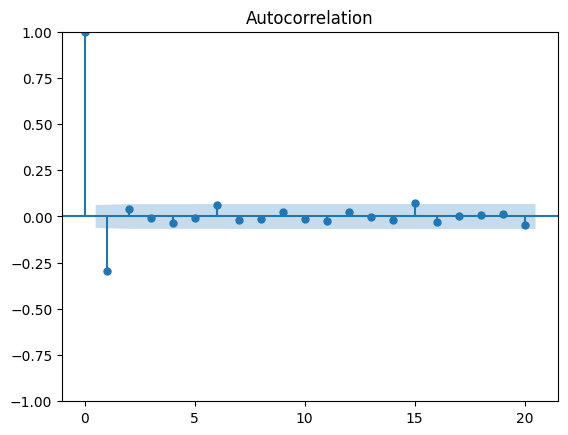

In [5]:
ar3 = np.array([1])
ma3 = np.array([1, -0.3])

MA_object3 = ArmaProcess(ar3, ma3)
simulated_data_3 = MA_object3.generate_sample(nsample = 1000)

# Plot 2: MA parameter = -0.3
plot_acf(simulated_data_3, lags = 20)
plt.show()

In [6]:
ar1 = np.array([1])
ma1 = np.array([1, -0.9])

MA_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = MA_object1.generate_sample(nsample = 1000)

# Fit an MA(1) model to the first simulated data
mod = ARIMA(simulated_data_1, order = (0, 0, 1))
res = mod.fit()

# Print out summary information on the fit
print(res.summary())

# Print out the estimate for the constant and for theta
print("When the true theta=-0.9, the estimate of theta is:")
print(res.params[1])

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1423.758
Date:                Sat, 28 Mar 2026   AIC                           2853.516
Time:                        23:54:55   BIC                           2868.240
Sample:                             0   HQIC                          2859.112
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.003     -0.142      0.887      -0.006       0.005
ma.L1         -0.9134      0.013    -69.677      0.000      -0.939      -0.888
sigma2         1.0079      0.045     22.512      0.0

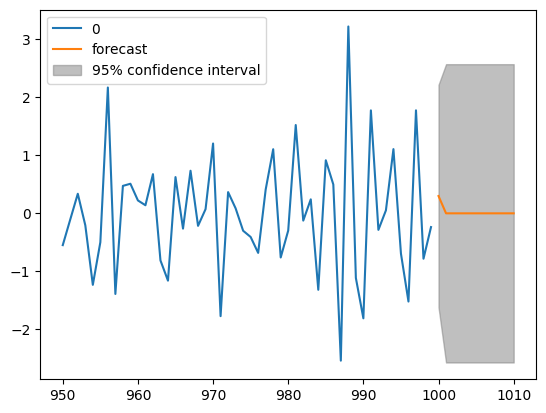

In [7]:
ar1 = np.array([1])
ma1 = np.array([1, -0.9])

MA_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = MA_object1.generate_sample(nsample = 1000)
simulated_data_1 = pd.DataFrame(simulated_data_1)

# Forecast the first MA(1) model
mod = ARIMA(simulated_data_1, order = (0, 0, 1))
res = mod.fit()

# Plot the data and the forecast
fig, ax = plt.subplots()
simulated_data_1.loc[950 : ].plot(ax = ax)
plot_predict(res, start = 1000, end = 1010, ax = ax)
plt.show()

DATE         str
CLOSE    float64
dtype: object
If there were no missing rows, there would be 391 rows of minute data
The actual length of the DataFrame is: 389
Missing rows:  {182, 14}


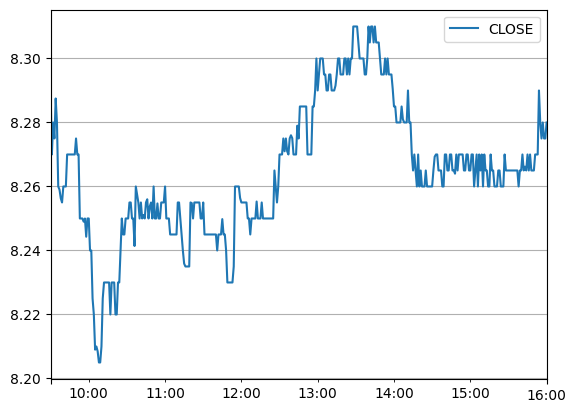

In [8]:
intraday = pd.read_csv('../Data/time_series/Sprint_Intraday.txt', usecols = [0, 1], header = None)

# Change the first date to zero
intraday.iloc[0, 0] = '0'

# Change the column headers to 'DATE' and 'CLOSE'
intraday.columns = ['DATE', 'CLOSE']

# Examine the data types for each column
print(intraday.dtypes)

# Convert DATE column to numeric
intraday['DATE'] = pd.to_numeric(intraday['DATE'])

# Make the `DATE` column the new index
intraday = intraday.set_index('DATE')

# Notice that some rows are missing
print("If there were no missing rows, there would be 391 rows of minute data")
print("The actual length of the DataFrame is:", len(intraday))

# Everything
set_everything = set(range(391))

# The intraday index as a set
set_intraday = set(intraday.index)

# Calculate the difference
set_missing = set_everything - set_intraday

# Print the difference
print("Missing rows: ", set_missing)

# Fill in the missing rows
intraday = intraday.reindex(range(391), method = 'ffill')

# From previous step
intraday = intraday.reindex(range(391), method='ffill')

# Change the index to the intraday times
intraday.index = pd.date_range(start = '2017-09-01 9:30', end = '2017-09-01 16:00', freq = '1min')

# Plot the intraday time series
intraday.plot(grid = True)
plt.show()

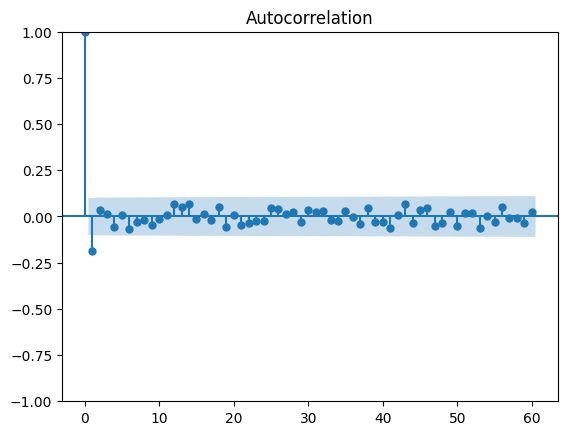

const    -6.832078e-06
ma.L1    -1.717162e-01
sigma2    4.150534e-07
dtype: float64


In [9]:
# Compute returns from prices and drop the NaN
returns = intraday.pct_change()
returns = returns.dropna()

# Plot ACF of returns with lags up to 60 minutes
plot_acf(returns, lags = 60)
plt.show()

# Fit the data to an MA(1) model
mod = ARIMA(returns, order = (0, 0, 1))
res = mod.fit()
print(res.params)

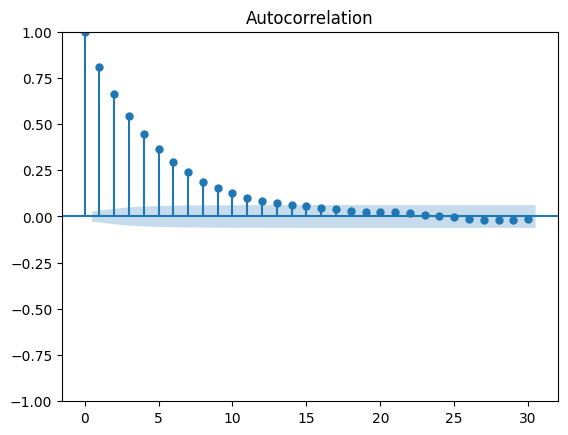

In [10]:
# Build a list MA parameters
ma = [0.8**i for i in range(30)]

# Simulate the MA(30) model
ar = np.array([1])
AR_object = ArmaProcess(ar, ma)
simulated_data = AR_object.generate_sample(nsample = 5000)

# Plot the ACF
plot_acf(simulated_data, lags = 30)
plt.show()